In [1]:
import numpy as np
import numpyro.distributions as dist
from numpyro.distributions import constraints

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')

import jax


import jax.numpy as jnp
from jax import random, jit
import jax
import copy

import pandas as pd
from scipy.stats import gaussian_kde as kde
from scipy.stats import norm

# import scarlet
import scarlet2
# from scarlet.display import AsinhMapping,AsinhPercentileNorm,show_scarlet2_scene,LinearPercentileNorm
# from scarlet.source import StaticSource,MultiExtendedSource, StaticMultiExtendedSource
from scarlet2 import *
from scarlet2 import relative_step
from scarlet2 import (
    Observation, Frame, Scene, Source, PointSource,
    init, relative_step, Parameter, StaticArraySpectrum, 
    TransientArraySpectrum
)
from scarlet2 import Starlet
from scarlet2.plot import AsinhPercentileNorm


import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.wcs import WCS
from astropy.io import fits
import astropy.io.fits as fits

import sys
import copy
import corner
import h5py
import os
import glob
import sep
from sep import Background, extract
import tarfile
import equinox as eqx
# import distrax
import optax
from tqdm.auto import tqdm
# import cmasher as cmr


from functools import partial
from skimage import draw
%matplotlib inline
# import astrophot as ap
pixelscale=0.17

# turn on automatic validation checks
from scarlet2.validation_utils import set_validation

# turn on automatic validation checks
set_validation(False)

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jaxtyping/__init__.py:231: UserWarning: jaxtyping version >=0.2.23 should be used with Equinox version >=0.11.1
  warnings.warn(
Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 614, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jax_plugins/xla_cuda13/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/jax_plugins/xla_cuda13/__init__.py", line 150, in _check_cuda_versions
    assert cuda_versions is not None
           ^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Load the Data + Define Observation and Frame: 
#### Get Rubin + 2 Roman data
get files and psfs, based on RubinRoman_TD-lc.ipynb \\

In [2]:
# ============================================================================
# 1. General File
# ============================================================================
# img_index = 1952
img_index = 96679  #17462 #96679
t_start = 56180   #start epoch I think? #mjdstart in rubinromanTD notebook
# times = np.arange(56150,56350,2)
t_off   = 56150
t_on    = 56200
n_roman_epochs = 2


times = [56150, 56154, 56158, 56162, 56166, 56170, 56180, 56190, 56200, 56210, 56210, 56220, 56230, 56240, 56250]

# times = [56150, 56154, 56158, 56162, 56166, 56170, 56182, 56190, 56200, 56210, 56210, 56220, 56230, 56240, 56250]
# times = [56150, 56154, 56158, 56160, 56162, 56164, 56166, 56168, 56170, 56172]
# times = np.arange(56150,56250,2)
# times = [56150, 56200]
epochs = [int(i) for i in range(len(times))] # basically just list of index keys correspond to each time?

path = '/scratch/network/vk9342/lenstronomy-tutorials/Notebooks/JP_spring_2025_modified_code/outputs/test/SNsims_TD_noise/'
data_path  = path + 'img_' + str(img_index) + '/'
psf_path   = '/scratch/network/vk9342/lenstronomy-tutorials/Notebooks/JP_spring_2025_modified_code/'

bands     = ["g","r","i"]
BANDS = ['G', 'R', 'I']
bandall = ['g','r','i','G','R','I']

channels = []
channels_on = []
observations = []
epochs_on = []

n_lsst  = len(bands) * len(times)   # e.g. 3 bands × (len(times) you picked)
n_roman  = len(BANDS) * n_roman_epochs   # 3 bands × 2 epochs = 6


In [3]:
# ============================================================================
# 2. PSF File paths for low Res Rubin
# ============================================================================
# psf_lsst_g_data  = fits.open(psf_path+'psf_LSST_g.fits')[0].data.astype('float32') 
# psf_lsst_i_data  = fits.open(psf_path+'psf_LSST_i.fits')[0].data.astype('float32') 
# psf_lsst_r_data  = fits.open(psf_path+'psf_LSST_r.fits')[0].data.astype('float32') 
# Np1, Np2        = psf_lsst_g_data.shape # not used anywhere??
# psf_lsst_      = jnp.asarray([psf_lsst_g_data, psf_lsst_r_data, psf_lsst_i_data])  #jnp.asarray([psf_lsst_data,psf_lsst_data,psf_lsst_data])
# psf_lsst       = scarlet2.ArrayPSF(psf_lsst_)


In [4]:
# ============================================================================
# 3. Load Observations for each Rubin epoch
# ============================================================================
for band in bands:
    for ind, epoch in enumerate(times):
        channel_sc2 = (band, int(ind)) 
        # save epoch ind corresponding to Roman images to append to channels later 
        if epoch == t_on:
            ind_t_on = str(ind)
        elif epoch == t_off:
            ind_t_off = str(ind)
        
        # get channels for only 'on' times
        if epoch >= t_start and epoch<t_start+100:  #Why 400 specifically?
            channels_on.append(channel_sc2)
            epochs_on.append(int(ind))
        
        #image files
        data_file_name = 'image_LSST_'+band+'_'+str(img_index)+'_newSN_'+str(epoch)+'.fits' #is this pre psf data?
        img = data_path+ data_file_name

        obs_hdu = fits.open(img)
        data_lsst = obs_hdu[0].data
        data_lsst = data_lsst.astype(data_lsst.dtype.newbyteorder('='))
        N1, N2 = data_lsst.shape
        data_lsst = data_lsst.reshape(1, N1, N2) #reshape because?
        obs_hduw = fits.open(os.path.join(data_path, 'image_LSST_'+band+'_wcs_'+str(img_index)+'_newSN_'+str(epoch)+'.fits')) # is this post psf data?
        wcs_lsst = WCS(obs_hduw[0].header)
        #data_lsst = jnp.array(np.asarray(data_lsst,dtype=float), jnp.float32) 

        psf_lsst_data  = fits.open(psf_path+'psf_LSST_'+band+'.fits')[0].data.astype('float32') 
        psf_lsst_      = jnp.asarray([psf_lsst_data])  #jnp.asarray([psf_lsst_data,psf_lsst_data,psf_lsst_data])
        psf_lsst       = scarlet2.ArrayPSF(psf_lsst_)

        #What should my weights be???????
        obs_lsst = scarlet2.Observation(jnp.asarray(data_lsst),
                                      wcs=wcs_lsst,
                                      psf=psf_lsst,
                                      channels=[channel_sc2],
                                      weights=None)
        observations.append(obs_lsst)

        channels.append(channel_sc2)


In [5]:
# ============================================================================
# 4. PSF file paths for high Res Roman
# ============================================================================
# psf_roman = fits.open(psf_path + "psf_Roman.fits")[0].data.astype('float32')  
# psf_roman = jnp.array(psf_roman, jnp.float32)

# psf_roman_single = jnp.asarray([psf_roman]) 
# psf_roman_single  = scarlet2.ArrayPSF(psf_roman_single)

# psf_roman_ = jnp.asarray([psf_roman])  #jnp.asarray([psf_roman,psf_roman,psf_roman])
# # Why line below for roman psf, but not rubin?
# psf_roman_ = (psf_roman_-np.min(psf_roman_))/(np.max(psf_roman_)-np.min(psf_roman_)) 
# psf_roman = scarlet2.ArrayPSF(psf_roman_)


In [6]:
# ============================================================================
# 5. Load high-res off/on images for Roman
# ============================================================================

t_on    = 56200
t_off   = 56150

#Read in a single epoch of high resolution imaging WITHOUT the SN
for band, BAND in zip(bands, BANDS):
    # Load the HST image data
    channel_sc2 = (BAND, int(ind_t_off))
    
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_"+str(img_index)+"_newSN_"+str(t_off)+".fits"))
    data_roman = roman_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('='))
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2)
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_wcs_"+str(img_index)+"_newSN_"+str(t_off)+".fits"))
    wcs_roman = WCS(roman_hdu[0].header)
    
    
    data_roman_offSN = jnp.array(np.asarray(data_roman,dtype=float), jnp.float32)
    # Scale the HST data
    n,n1, n2 = jnp.shape(data_roman)
    #data_hst *= data_hsc.max() / data_hst.max()
    N,N1, N2 = data_roman.shape

    psf_roman = fits.open(psf_path + "psf_Roman_"+band+".fits")[0].data.astype('float32')  
    psf_roman = jnp.array(psf_roman, jnp.float32)
    psf_roman_single = jnp.asarray([psf_roman]) 
    psf_roman_single  = scarlet2.ArrayPSF(psf_roman_single)
    psf_roman_ = jnp.asarray([psf_roman])  #jnp.asarray([psf_roman,psf_roman,psf_roman])
    # Why line below for roman psf, but not rubin?
    psf_roman_ = (psf_roman_-np.min(psf_roman_))/(np.max(psf_roman_)-np.min(psf_roman_)) 
    psf_roman = scarlet2.ArrayPSF(psf_roman_)

    # define two observation packages and match to frame
    obs_roman_offSN = scarlet2.Observation(data_roman,
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights=None) #should weights be none?    
    
    channels.append(channel_sc2)
    observations.append(obs_roman_offSN)



#Read in a single epoch of high resolution imaging WITH the SN
for band, BAND in zip(bands, BANDS):

    channel_sc2 = (BAND, int(ind_t_on))
    
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_"+str(img_index)+"_newSN_"+str(t_on)+".fits"))
    data_roman = roman_hdu[0].data
    data_roman = data_roman.astype(data_roman.dtype.newbyteorder('='))
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2)
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_wcs_"+str(img_index)+"_newSN_"+str(t_off)+".fits"))  
    wcs_roman = WCS(roman_hdu[0].header)
    print(wcs_roman)
    #data_roman = jnp.array(np.asarray(data_roman,dtype=float), jnp.float32)
    # Load the HST PSF data

    psf_roman = fits.open(psf_path + "psf_Roman_"+band+".fits")[0].data.astype('float32')  
    psf_roman = jnp.array(psf_roman, jnp.float32)
    psf_roman_single = jnp.asarray([psf_roman]) 
    psf_roman_single  = scarlet2.ArrayPSF(psf_roman_single)
    psf_roman_ = jnp.asarray([psf_roman])  #jnp.asarray([psf_roman,psf_roman,psf_roman])
    # Why line below for roman psf, but not rubin?
    psf_roman_ = (psf_roman_-np.min(psf_roman_))/(np.max(psf_roman_)-np.min(psf_roman_)) 
    psf_roman = scarlet2.ArrayPSF(psf_roman_)
    
    
    if float(epoch)>t_start and float(epoch)<t_start+100:
        channels_on.append(channel_sc2)
    
    # define two observation packages and match to frame
    obs_roman_postSN = scarlet2.Observation(jnp.asarray(data_roman),
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights=None) #should weights be none? 
    
    channels.append(channel_sc2)
    observations.append(obs_roman_postSN)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2.0 28.0 
CD1_1 CD1_2  : -3.0555555555555e-05 -0.0 
CD2_1 CD2_2  : 0.0 3.05555555555555e-05 
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2.0 28.0 
CD1_1 CD1_2  : -3.0555555555555e-05 -0.0 
CD2_1 CD2_2  : 0.0 3.05555555555555e-05 
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2.0 28.0 
CD1_1 CD1_2  : -3.0555555555555e-05 -0.0 
CD2_1 CD2_2  : 0.0 3.05555555555555e-05 
NAXIS : 55  55


In [7]:
#How many observations did we end up reading in? Should be at least a few
print(len(observations))

51


In [8]:
# ============================================================================
# 6. Make Frame and match observations
# ============================================================================
# model_frame_psf = scarlet2.GaussianPSF(0.7)
model_frame = scarlet2.Frame.from_observations(
    observations=observations,
    coverage="union"  # or "intersection"
    )

for obs in observations:
    obs.match(model_frame)

### Find Sources

In [9]:
# ============================================================================
# 7. Find sourced in image - from RubinRoman_TD notebook
# ============================================================================

def makeCatalog(observations, lvl=3, wave=True, SNR=2.0):
    
    normed_images = np.asarray([obs.data[0] for obs in observations])
    interps = normed_images
    
    interps = np.asarray(interps/np.sum(interps))
    detect_image = np.sum(interps,axis=(0))
    # Wavelet transform
    # wave_detect = scarlet.Starlet.from_image(detect_image).coefficients
    wave_detect = Starlet.from_image(detect_image).coefficients

    if wave:
        # Creates detection from the first 3 wavelet levels
        detect = wave_detect[:lvl,:,:].sum(axis = 0)
    else:
        detect = detect_image

    detect = np.array(detect)

    # Runs SEP detection
    bkg = sep.Background(detect)
    catalog = sep.extract(detect-bkg.globalback, SNR, err=bkg.globalrms)
    background=[]
    bg_rms=[]
    for ind in range(len(observations)):
        img = copy.copy(np.asarray(observations[ind].data))
        if np.size(img.shape) == 3:
            bg_rms.append(np.array([sep.Background(band).globalrms for band in img]))
            background.append(np.array([sep.Background(band).globalback for band in img]))
        else:
            bg_rms.append(sep.Background(img).globalrms)
            background.append(sep.Background(img).globalback)
    return catalog, bg_rms, detect_image, background

In [10]:
# ============================================================================
# 8. Find sources in image - from RubinRoman_TD notebook
# USE ROMAN IMAGES ONLY
# ============================================================================

#If the source detection is not finding all the sources, you can first try to adjust these three parameters to help it find the sources
lvl=1
wave=2
SNR=2.0

lsst_obs = observations[:-n_roman]
roman_obs = observations[-n_roman:]

observations_sc2=[]
normsingle=[]

# ============================================================================   
# DETECT SOURCES BASED ONLY ON ROMAN IMGS
catalog_single_roman, bgsingle_roman, detectsingle_roman, globalback_roman = makeCatalog(roman_obs, lvl, wave)
pixel = np.stack((catalog_single_roman['y'], catalog_single_roman['x']), axis=1)
ra_dec = pixel
print(ra_dec.shape)
# ============================================================================

(4, 2)


In [11]:
#################################################################################
### MAKE observations_sc2 ###########################
bgarr_roman     = np.asarray(bgsingle_roman)
bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asarray(bgsingle_roman).flatten()))
bgarr_roman     = np.asarray(bgsingle_roman)
print(bgarrall_roman.shape)

catalog_single_lsst, bgsingle_lsst, detectsingle_lsst, globalback_lsst = makeCatalog(lsst_obs, lvl, wave)
bgarr_lsst    = np.asarray(bgsingle_lsst)
bgarrall_lsst = np.hstack((bgarr_lsst.flatten(),np.asarray(bgsingle_lsst).flatten()))
bgarr_lsst    = np.asarray(bgsingle_lsst)
print(bgarrall_lsst.shape)


bgr_lsst = np.array([b[0] for b in bgarr_lsst])
bgr_roman = np.array([b[0] for b in bgarr_roman])
bgarr_all = np.concatenate([bgr_lsst, bgr_roman], axis=0)

gb_lsst = np.array([b[0] for b in globalback_lsst])
gb_roman = np.array([b[0] for b in globalback_roman])
globalback_all = np.concatenate([gb_lsst, gb_roman], axis=0)

print(len(bgarr_all))
print(len(globalback_all))


for ind,(obs2, bg, back) in enumerate(zip(observations, bgarr_all, globalback_all)):

    print(ind)
    
    w = obs2.frame.wcs
    psf = obs2.frame.psf
    weights2=np.ones(obs2.data.shape) / (bg**2)#[:, None, None]  #??in RubinRoman notebook insteads of bg it uses bgarr_all, is this a typo?
    data = obs2.data-back   #Subtract background flux

    print(channels[ind])
    
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf,channels=[channels[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    # print("obs2.data shape:", obs2.data.shape, '\n')
    # print('obs2.data: ', obs2.data, '\n')
    # print('obs2.data[:,10:-10,10:-10]:', obs2.data[:,10:-10,10:-10], '\n')

    
    #Store norm based on observation data
    normsingle.append(
        AsinhPercentileNorm(
            jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
            percentiles=[0.001, 50, 80])
    )


# # ============================================================================   
# # obssinglearr=np.asarray(observations) --> not used anywhere?
# bgarr_roman     = np.asfarray(bgsingle_roman)
# bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asfarray(bgsingle_roman).flatten()))
# bgarr_roman     = np.asfarray(bgsingle_roman)
# print(bgarrall_roman.shape)

# normsingle=[]

# for ind,(obs2,bg,back) in enumerate(zip(roman_obs,bgarr_roman,globalback_roman)):
#     w = obs2.frame.wcs
#     weights2=np.ones(obs2.data.shape) / (10*bgarr_roman**2)[:, None, None]
#     #Subtract background flux
#     data = obs2.data-back
    
#     obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf_roman,channels=[channels[ind]],wcs=w)
#     observations_sc2.append(obs_sc2)
    
#     #Store norm based on observation data
#     normsingle.append(
#         AsinhPercentileNorm(
#             jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
#             percentiles=[0.001, 50, 80])
#     )
#     ## the 50 above is random, it gave an error asking for a third number



(12,)
(90,)
51
51
0
('g', 0)
1
('g', 1)
2
('g', 2)
3
('g', 3)
4
('g', 4)
5
('g', 5)
6
('g', 6)
7
('g', 7)
8
('g', 8)
9
('g', 9)
10
('g', 10)
11
('g', 11)
12
('g', 12)
13
('g', 13)
14
('g', 14)
15
('r', 0)
16
('r', 1)
17
('r', 2)
18
('r', 3)
19
('r', 4)
20
('r', 5)
21
('r', 6)
22
('r', 7)
23
('r', 8)
24
('r', 9)
25
('r', 10)
26
('r', 11)
27
('r', 12)
28
('r', 13)
29
('r', 14)
30
('i', 0)
31
('i', 1)
32
('i', 2)
33
('i', 3)
34
('i', 4)
35
('i', 5)
36
('i', 6)
37
('i', 7)
38
('i', 8)
39
('i', 9)
40
('i', 10)
41
('i', 11)
42
('i', 12)
43
('i', 13)
44
('i', 14)
45
('G', 0)
46
('R', 0)
47
('I', 0)
48
('G', 8)
49
('R', 8)
50
('I', 8)


In [12]:
# ### Debugging inhomogeneous part
# for i, obs in enumerate(lsst_obs):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [13]:
# # Debug shapes before stacking
# for i, obs in enumerate(lsst_obs):
#     print(f"Index {i} -> obs.data[0] shape: {obs.data[0].shape}")

In [14]:
# model_frame_psf = scarlet2.GaussianPSF(0.4)
model_frame = scarlet2.Frame.from_observations(
    observations=observations_sc2,
    coverage="union",  # or "intersection"
)
for obs in observations_sc2:
    obs.match(model_frame)

### Initialize Sources

In [15]:
# ============================================================================
# 10. Source initialization
# ============================================================================
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

band_selector  = lambda ch: ch[0]
epoch_selector = lambda ch: ch[1]


In [16]:
# ============================================================================
# 9. Get and visualize sources in image
# ============================================================================
world_coords = []
for y, x in ra_dec:
    sky = wcs_roman.pixel_to_world(x, y)   # note: pixel_to_world(x, y)
    world_coords.append(SkyCoord(sky.ra, sky.dec))

roman_pixel_coords = [wcs_roman.world_to_pixel(sky) for sky in world_coords]
lsst_pixel_coords = [wcs_lsst.world_to_pixel(sky) for sky in world_coords]

## Ra and dec centers from SEP catalog
sky_coords_ = world_coords

In [17]:
print("Detected source pixel coordinates:")
for i, (y, x) in enumerate(ra_dec, start=1):
    print(f"  Source {i:>2d}: x = {x:.2f}, y = {y:.2f}")

print("\nDetected source sky coordinates:")
for i, sky in enumerate(world_coords, start=1):
    # in decimal degrees:
    print(f"  Source {i:>2d}: RA = {sky.ra.deg:.6f}°,  Dec = {sky.dec.deg:.6f}°")

print("\nBack to LSST pixel coords:")
for i, (x_lsst, y_lsst) in enumerate(lsst_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_lsst:.2f},  y = {y_lsst:.2f}")

print("\nBack to Roman pixel coords:")
for i, (x_roman, y_roman) in enumerate(roman_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_roman:.2f},  y = {y_roman:.2f}")


Detected source pixel coordinates:
  Source  1: x = 27.00, y = 26.19
  Source  2: x = 23.24, y = 29.46
  Source  3: x = 27.81, y = 31.00
  Source  4: x = 33.22, y = 28.13

Detected source sky coordinates:
  Source  1: RA = 359.999206°,  Dec = -0.000025°
  Source  2: RA = 359.999320°,  Dec = 0.000075°
  Source  3: RA = 359.999181°,  Dec = 0.000122°
  Source  4: RA = 359.999015°,  Dec = 0.000034°

Back to LSST pixel coords:
 Source 1:  x = 15.30,  y = 14.56
 Source 2:  x = 13.23,  y = 16.35
 Source 3:  x = 15.74,  y = 17.20
 Source 4:  x = 18.72,  y = 15.62

Back to Roman pixel coords:
 Source 1:  x = 27.00,  y = 26.19
 Source 2:  x = 23.24,  y = 29.46
 Source 3:  x = 27.81,  y = 31.00
 Source 4:  x = 33.22,  y = 28.13


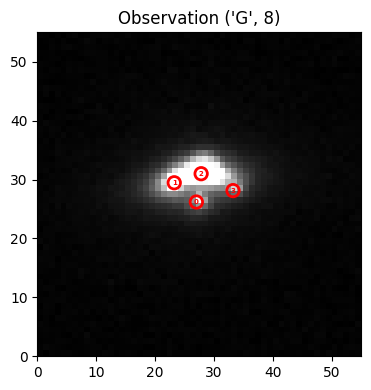

In [18]:
# draw the observation into the current axes
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

scarlet2.plot.observation(
    observation=observations[48],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)

# get current axis
ax = plt.gca()

# loop over sources and draw both red circle and index label
for i, (x0, y0) in enumerate(roman_pixel_coords):
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )

    # Add index label
    ax.text(
        x0, y0,
        str(i),
        color='red',
        fontsize=5,
        ha='center',
        va='center',
        weight='bold'
    )

plt.show()


In [19]:
# ============================================================================
# 10.2 Get coords of source in center of image (assume it is the lens)
# ============================================================================

'''
Modify sources based on system
--> adapt list sky_coords
--> adapt is extended
'''

#### Check if in center of image:
roman_obs_sc2_on = roman_obs_sc2[-1]
_, H, W   = roman_obs_sc2_on.data.shape               # data.shape = (C, H, W)
center_pix = np.array([W//2, H//2], dtype=int)        # [x_center, y_center] in Roman coords
tol_pix    = 3                                        # how close (in px) counts as “at centre”
is_center = []


center_pix_sky = wcs_roman.pixel_to_world(center_pix[0], center_pix[1])
center_pix_sky_coords = SkyCoord(center_pix_sky.ra, center_pix_sky.dec)
# print(center_pix_sky_coords, '\n')
# print(sky_coords_, '\n')


for i, roman_pix_coords in enumerate(roman_pixel_coords):
    is_center.append(np.all(np.abs(roman_pix_coords - center_pix) <= tol_pix))
    print(f"Source {i} at pixel {roman_pix_coords}, centre is {center_pix}, is_center={is_center[i]}")
print('is_center: ', is_center, '\n')


sky_coords = sky_coords_ #+ [center_pix_sky_coords]

sky_coords = sky_coords + [sky_coords[0]] # add PS at same location as 1s source ie host
del sky_coords[1]   #delete second source on lens to the left



print(sky_coords, '\n')
for i, sky_coord in enumerate(sky_coords):
    print(f"Source {i} at pixel {wcs_roman.world_to_pixel(sky_coord)}, centre is {center_pix}, is_center={is_center[i]}")

is_extended = [True, True, False, False]
print(is_extended)
    

Source 0 at pixel (array(26.9964308), array(26.1932166)), centre is [27 27], is_center=True
Source 1 at pixel (array(23.244221), array(29.45792675)), centre is [27 27], is_center=False
Source 2 at pixel (array(27.80904452), array(30.99784517)), centre is [27 27], is_center=False
Source 3 at pixel (array(33.22122146), array(28.12826392)), centre is [27 27], is_center=False
is_center:  [True, False, False, False] 

[<SkyCoord (ICRS): (ra, dec) in deg
    (359.99920566, -2.46517151e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99918083, 0.00012216)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99901546, 3.44747308e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99920566, -2.46517151e-05)>] 

Source 0 at pixel (array(26.9964308), array(26.1932166)), centre is [27 27], is_center=True
Source 1 at pixel (array(27.80904452), array(30.99784517)), centre is [27 27], is_center=False
Source 2 at pixel (array(33.22122146), array(28.12826392)), centre is [27 27], is_center=False
Source 3 at 

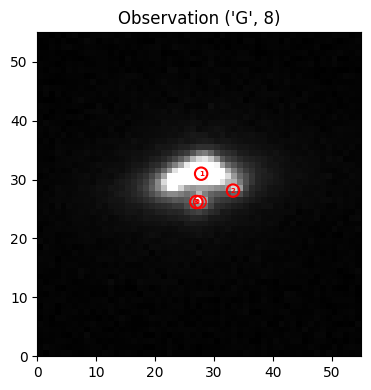

In [44]:
scarlet2.plot.observation(
    observation=observations[48],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)

# get current axis
ax = plt.gca()

# # loop over sources and draw both red circle and index label
for i, sky_coord_i in enumerate(sky_coords):
    x0, y0 = wcs_roman.world_to_pixel(sky_coord_i)
    x0, y0 = float(x0), float(y0)

    # Draw red circle
    if i ==0:
        ax.scatter(
            x0+0.6, y0,
            s=80,
            edgecolors='red',
            facecolors='none',
            linewidths=1
    )
    else:  
        ax.scatter(
            x0, y0,
            s=80,
            edgecolors='red',
            facecolors='none',
            linewidths=1.5
        )

    # Add index label
    if i ==0:
        ax.text(
            x0+0.2, y0,
            str(i),
            color='red',
            fontsize=5,
            ha='center',
            va='center',
            weight='bold'
        )
    else:
        ax.text(
            x0, y0,
            str(i),
            color='red',
            fontsize=5,
            ha='center',
            va='center',
            weight='bold'
        )

# plt.savefig(str(img_index)+'_source_detection_roman.png')
plt.show()

In [45]:
# # ============================================================================
# # 10.1 Classify if source is extended/point source based on PSF
# # ============================================================================


# ##  Measure each detection's “size” via Gaussian moments
# ## Determine whether > or < than PSF
# ## if > then PSF then categorize as extended source
# ## if < than PSF then categorize as point source
# ## IS THE BELOW CORRECT ??????????    
# sizes      = []
# is_extended = []
# psf_sigma = model_frame.psf.morphology.size   # sigma of GaussianPSF in pixels
# for coords in sky_coords:
#     try:
#         with Scene(model_frame):  # should I only do roman here??
#             coords_list = [coords] * n_roman
#             #?? is coords supposed to be a list of touples of length len (obs) because I get an error if I just put one touple??
#             roman_spectrum, roman_morphology = init.from_gaussian_moments(roman_obs_sc2, coords_list, min_snr=0.1) 
        
#         morph = np.array(roman_morphology.data)
#         M00 = morph.sum()                            # zeroth moment
#         ys, xs = np.indices(morph.shape)             # pixel grid
#         xc = (xs * morph).sum() / M00                  # 1st moment → centroid x
#         yc = (ys * morph).sum() / M00                  # 1st moment → centroid y
#         Mxx = ((xs - xc)**2 * morph).sum() / M00     # 2nd central moment
#         Myy = ((ys - yc)**2 * morph).sum() / M00     # 2nd central moment
#         sigma = np.sqrt(0.5 * (Mxx + Myy))         # mean 1σ size
#         sizes.append(sigma)
#         ## extended if > PSF size by 20%
#         is_extended.append(sigma > psf_sigma * 1.2)
    
#     except ValueError:
#         ## Gaussian fit failed: treat as point
#         sizes.append(None)
#         is_extended.append(False)
#         print('Gaussian fit failed')

# print(is_extended)



In [46]:
print(channels)
print(epochs)

[('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('G', 0), ('R', 0), ('I', 0), ('G', 8), ('R', 8), ('I', 8)]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [47]:
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

In [48]:
# ============================================================================
# 10.3 Source initialization (point vs extended + Gaussian‐moment sizes)
# ============================================================================
## Build the Scarlet Scene with one Source per detection
lens_indx = 1
with Scene(model_frame) as scene:
    for i, coords  in enumerate(sky_coords):

        ##############################################################        
        ##############################################################
        ## EXTENDED SOURCE (e.g. host galaxy) 
        if is_extended[i]:
            print(f"Source {i}: EXTENDED ")
            if i == lens_indx:  #len(sky_coords)-1
                print('lens')
            else:
                print('host')
            try: 
                print('trying from_gaussian_moments')
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    min_snr = 0.001
                )
                
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,
                    min_snr = 0.001
                )
                morphology = morphology_roman
                
                
            ## Use compact_morphology if gaussian moments fails
            except:# IndexError:
                print('Using gaus2d')
                if i == lens_indx:  #added lens box
                    x = np.linspace(-10, 10, 40)
                    y = np.linspace(-10, 10, 40)
                    x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                    morphology = gaus2d(x, y, sx=3,sy=3)
                else:
                    x = np.linspace(-10, 10, 30)
                    y = np.linspace(-10, 10, 30)
                    x, y = np.meshgrid(x, y) # get 2D variables instead of 1D
                    morphology = gaus2d(x, y, sx=2, sy=2)
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)

            
            print('morphology.shape before padding: ', morphology.shape)
            ## initialize with  Starlet Array Morphology
            if i == lens_indx:                      #lens
                pad = int((30 - morphology.shape[0])/2)
            else:                                           #host
                pad = int((20 - morphology.shape[0])/2)
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')
            # morph = scarlet2.StarletMorphology.from_image(morph)
            morph = jnp.asarray(morph)
            
            print('morphology.shape after padding: ', morph.shape)
            
            ## join lsst and roman fluxes
            fluxes = 3*np.hstack((spectrum_lsst,spectrum_roman))
            fluxes[fluxes<1e-6]=1e-1
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    bands=bandall,   #[g, r, i, G, R, I]
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)
        
        ########################################################################
        # POINT SOURCE (transient/SN) —
        else:
            print(f"Source {i}: POINT SOURCE")
            spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
            spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
            # the above returns arrays containing fluxes for ALL images, but sets the roman/lsst image fluxes to 0 in spectrum_lsst/roman
            spectrum_lsst = spectrum_lsst[:n_lsst]
            spectrum_roman = spectrum_roman[n_lsst:]
            flux_var = np.hstack((spectrum_lsst, spectrum_roman))
            flux_var[flux_var<1e-6]=1e-1  #from RubinRoman_TD
            flux_var[np.isnan(flux_var)]=1e-1 #from RubinRoman_TD

            # Set off epoch flux to 0 (small value)
            for j, (band, epoch) in enumerate(channels):
                if str(epoch) not in epochs_on:
                    flux_var[j] = 1e-10  # Or 0.0 if you're confident it's safe
    
            # flux = jnp.asarray(flux)

            # Build mask of al the “off‐SN” channels
            # Set flux for off channels to 1e-20 (almost 0, avoid division w 0 later on)
            # off_mask = [i for i,ch in enumerate(channels) if ch not in channels_on]
            flux = jnp.asarray(3*flux_var)
            # off_idx = jnp.array(off_mask, dtype=jnp.int32)
            # flux = flux.at[off_idx].set(1e-20)
            print(flux)
            
            transient_spectrum = scarlet2.TransientArraySpectrum(
                    flux,
                    epochs=epochs_on,#epochs, # all epochs or channels_zeroed?
                    epoch_selector=epoch_selector
                )
            scarlet2.PointSource(coords, transient_spectrum)
            

# By now `scene.sources` contains your point/transient sources and extended source(s).
print(scene)

Source 0: EXTENDED 
host
trying from_gaussian_moments
Channel '('g', 0)' not found in observations. Setting amplitude to 0.
Channel '('g', 1)' not found in observations. Setting amplitude to 0.
Channel '('g', 2)' not found in observations. Setting amplitude to 0.
Channel '('g', 3)' not found in observations. Setting amplitude to 0.
Channel '('g', 4)' not found in observations. Setting amplitude to 0.
Channel '('g', 5)' not found in observations. Setting amplitude to 0.
Channel '('g', 6)' not found in observations. Setting amplitude to 0.
Channel '('g', 7)' not found in observations. Setting amplitude to 0.
Channel '('g', 8)' not found in observations. Setting amplitude to 0.
Channel '('g', 9)' not found in observations. Setting amplitude to 0.
Channel '('g', 10)' not found in observations. Setting amplitude to 0.
Channel '('g', 11)' not found in observations. Setting amplitude to 0.
Channel '('g', 12)' not found in observations. Setting amplitude to 0.
Channel '('g', 13)' not found in 

In [49]:
# print(spectrum_lsst)
# print(spectrum_roman)
# print("→ channels in observations_sc2:")
# for obs in lsst_obs_sc2:
#    print(obs.frame.channels)
# print(flux)


# print("flux.shape =", flux.shape)   # should print (2, 6)
# print("spectrum.data.shape =", transient_spectrum.data.shape)  # should be (2,6)
# print("frame channels:", model_frame.channels)
# for ch in model_frame.channels:
#     print(ch, "→ band_selector:", band_selector(ch),
#                  " epoch_selector:", epoch_selector(ch))

print(epochs_on)
# # Check initialized fluxes
# for i, src in enumerate(scene.sources):
#     print(f"\nSource {i} - Initial SED (fluxes):")
#     for (band, epoch), flux_val in zip(channels, src.spectrum.data):
#         print(f"  Band: {band}, Epoch: {epoch} → Flux: {flux_val:.4f}")
# # Check initialized fluxes
# for i, src in enumerate(scene.sources):
#     print(f"\nSource {i} - Initial SED (fluxes):")
#     for (band, epoch), flux_val in zip(channels, src.spectrum.data):
#         print(f"  Band: {band}, Epoch: {epoch} → Flux: {flux_val:.4f}")

print(scene.sources[0].spectrum.data)

[6, 7, 8, 9, 10, 11, 12, 13, 14, 6, 7, 8, 9, 10, 11, 12, 13, 14, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[2.7781161e-03 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 7.3329322e-03 2.6157999e-04
 2.6157999e-04 1.0000000e-01 5.5894209e-03 1.0000000e-01 6.9151418e-03
 6.4295654e+00 1.0000000e-01 1.0000000e-01 6.4995708e+00 6.5016394e+00
 6.4646807e+00 6.4506826e+00 1.0000000e-01 1.0257683e+01 1.0380133e+01
 1.0380133e+01 1.0897092e+01 9.5647869e+00 8.0105639e+00 7.3662043e+00
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.0000000e-01
 1.0000000e-01 1.0000000e-01 1.0000000e-01 1.000000

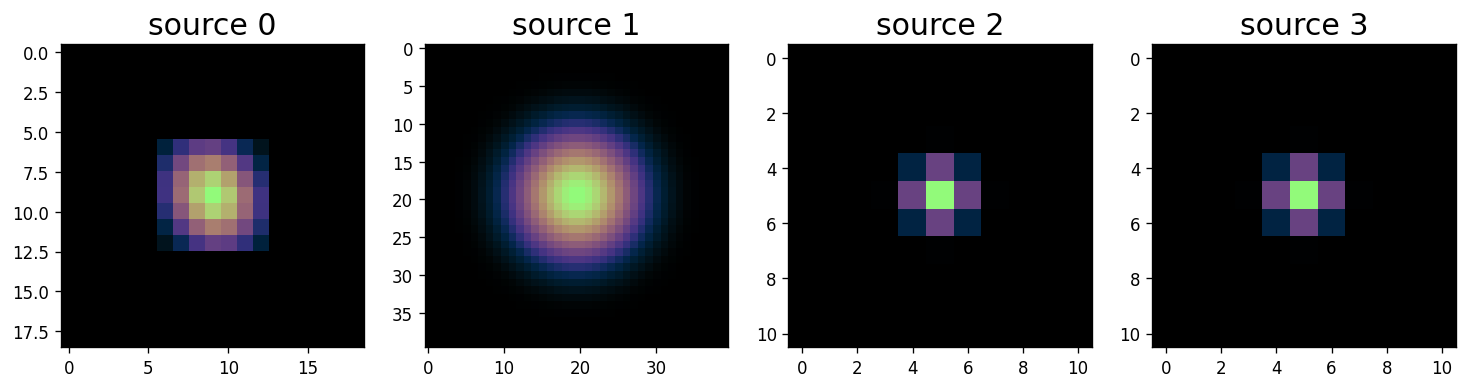

<Figure size 640x480 with 0 Axes>

In [52]:
import cmasher as cmr
cmap = cmr.lilac
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:#i!=indtransient:
        y = np.array(scene.sources[i].morphology)  # should work if it's already 2D or 3D
    else:
        y = scene.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()
plt.savefig(str(img_index)+'_source_models.png')
plt.show()
plt.clf()

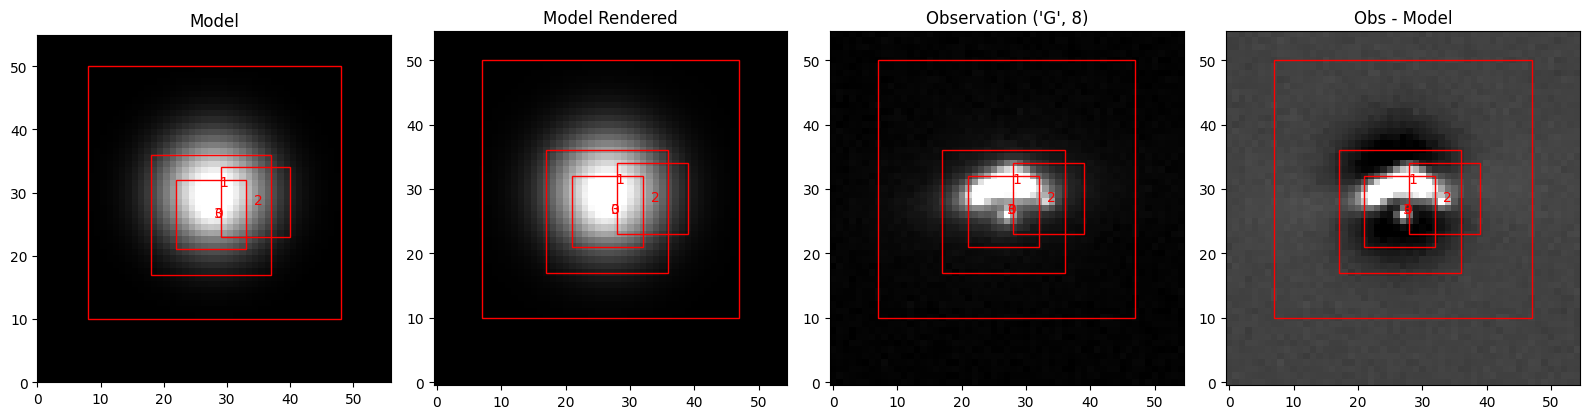

In [54]:
#print(obs_hsc.data.shape,obs_hst.data.shape)
#print(frameall.channels,channels_zeroed)
#print(obs_hsc.render(scene()).shape,obs_hst.render(scene()).shape)
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[48],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)

plt.savefig(str(img_index)+'_scene_prefit_roman.png')
plt.show()

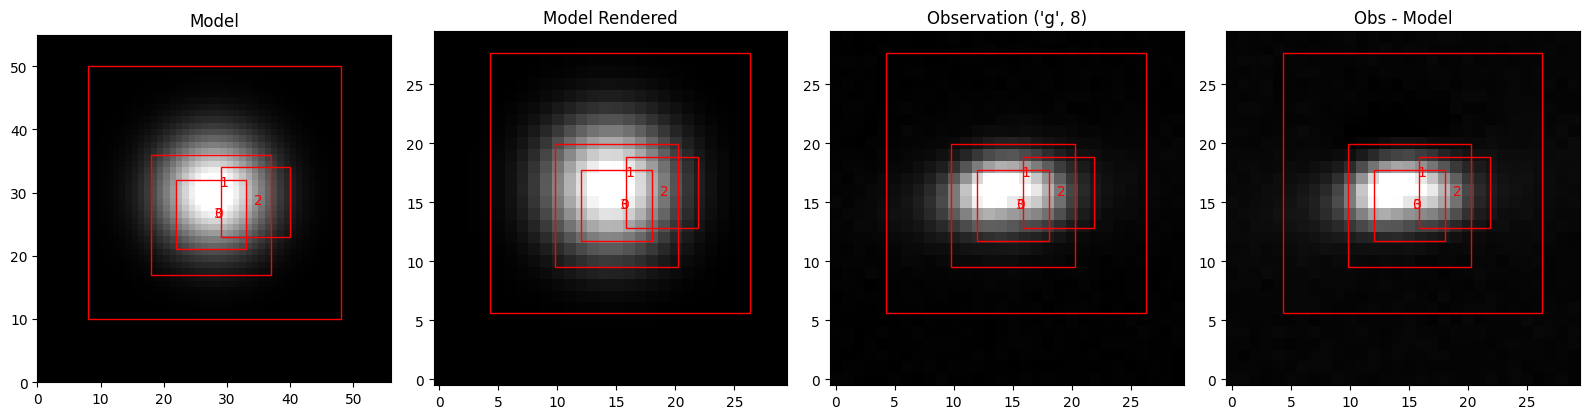

In [56]:
# Plot the model, for each epoch
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[8],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)
plt.savefig(str(img_index)+'_scene_prefit_rubin.png')
plt.show()


### Fitting

In [57]:
pos_step = 1e-3                                                   #change if SN positions look bad
morph_step = lambda p: scarlet2.relative_step(p, factor=1e-4)     #change factor if host/lens looks bad
SED_step = lambda p: scarlet2.relative_step(p, factor=1e-4)       #change factor if SN flux looks bad

parameters = scene.make_parameters()

with Parameters(scene) as parameters:
    for source_indx in range(len(scene.sources)):
    
        print(source_indx)
        
        scarlet2.Parameter(scene.sources[source_indx].spectrum.data, 
                                         name=f"spectrum.{source_indx}", 
                                         constraint=constraints.positive, stepsize=SED_step
                                        )   #are constrains supposed to be included? no in scarlet2 docs
    
        if is_extended[source_indx]:
            #Static host galaxy parameters; or lens
            scarlet2.Parameter(scene.sources[source_indx].morphology, #morphology.data or morphology.coeffs
                                             name=f"morph.{source_indx}", stepsize=morph_step
                                            )#, prior=prior)
            
        else:
            #Transient point source parameters
            scarlet2.Parameter(scene.sources[source_indx].center, 
                                             name=f"center.{source_indx}", 
                                             constraint=constraints.positive, stepsize=pos_step
                                            )
             
        
            

0
1
2
3


In [58]:
for k, src in enumerate(scene.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

Source 0, Fluxes: [0.06368091 0.06368091 0.06368091 0.06368091 0.06368091 0.06368091
 0.06368091 0.06368091 0.06368091 0.06368091 0.06368091 0.06368091
 0.06368091 0.06368091 0.06368091 2.2922337  2.2922337  2.2922337
 2.2922337  2.2922337  2.2922337  2.2922337  2.2922337  2.2922337
 2.2922337  2.2922337  2.2922337  2.2922337  2.2922337  2.2922337
 2.2922337  2.2922337  2.2922337  2.2922337  2.2922337  2.2922337
 2.2922337  2.2922337  2.2922337  2.2922337  2.2922337  2.2922337
 2.2922337  2.2922337  2.2922337  2.2922337  2.2922337  2.2922337
 2.2922337  2.2922337  2.2922337 ]
Source 1, Fluxes: [228.13144 228.13144 228.13144 228.13144 228.13144 228.13144 228.13144
 228.13144 228.13144 228.13144 228.13144 228.13144 228.13144 228.13144
 228.13144 231.04492 231.04492 231.04492 231.04492 231.04492 231.04492
 231.04492 231.04492 231.04492 231.04492 231.04492 231.04492 231.04492
 231.04492 231.04492 231.50531 231.50531 231.50531 231.50531 231.50531
 231.50531 231.50531 231.50531 231.50531 231

In [59]:
# Fit the scene
stepnum = 3000
scene_ = scene.fit(observations_sc2, parameters, max_iter=stepnum, e_rel=1e-4, progress_bar=True)


  0%|          | 0/3000 [00:00<?, ?it/s]

In [60]:

import scarlet2.io as io
id = 13
filename = str(img_index) + "_scarlet2_model.h5"
io.model_to_h5(scene_, filename, id=id, overwrite=True)

In [61]:
print("----------------- {}".format(channels))
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

----------------- [('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('G', 0), ('R', 0), ('I', 0), ('G', 8), ('R', 8), ('I', 8)]
Source 0, Fluxes: [  -0.12175389   -0.12175389   -0.12175389   -0.12175389   -0.12175389
   -0.12175389   -0.12175389   -0.12175389   -0.12175389   -0.12175389
   -0.12175389   -0.12175389   -0.12175389   -0.12175389   -0.12175389
   -1.6408997    -1.6408997    -1.6408997    -1.6408997    -1.6408997
   -1.6408997    -1.6408997    -1.6408997    -1.6408997    -1.6408997
   -1.6408997    -1.6408997    -1.6408997    -1.6408997    -1.6408997
   -2.1807024  

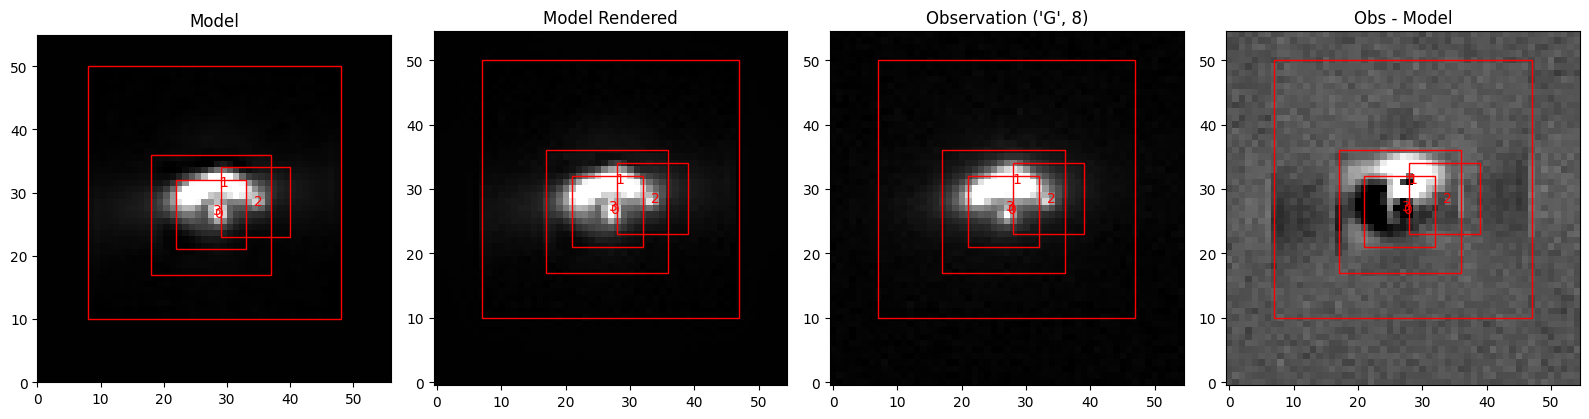

In [68]:
# Plot the model, for each epoch
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[48],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)
plt.show()


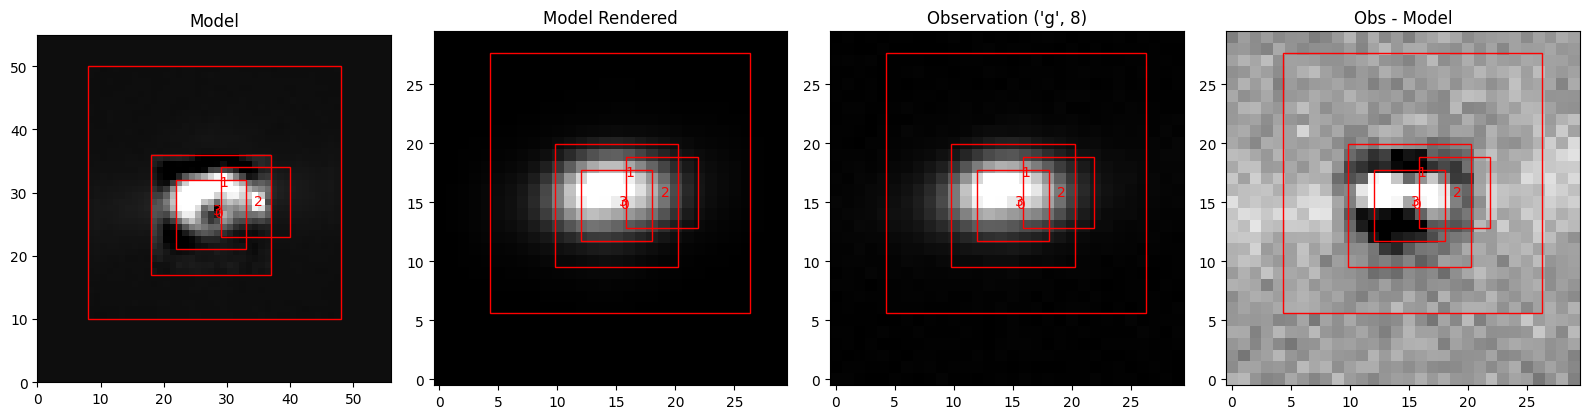

In [63]:
# Plot the model, for each epoch
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[8],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)
plt.show()


In [64]:
## Restructure fluxes into array like lenstronomy structure
# Only Rubin fluxes

#[
#  [  # g-band
#    [flux_source0_epoch0, flux_source1_epoch0, ..., flux_sourceN_epoch0],
#    [flux_source0_epoch1, flux_source1_epoch1, ..., flux_sourceN_epoch1],
#    ...
#  ],

#  [  # r-band
#    [...],
#    ...
#  ],

#  [  # i-band
#    [...],
#    ...
#  ]
#]


In [65]:
import pickle

# Define Rubin bands of interest
rubin_bands = ['g', 'r', 'i']

# Get indices of (band, epoch) for each Rubin band
band_epoch_indices = {band: [] for band in rubin_bands}
for idx, (band, epoch) in enumerate(channels):
    if band in rubin_bands:
        band_epoch_indices[band].append((int(epoch), idx))

# Get indices of point sources (is_extended == False)
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
num_point_sources = len(point_source_indices)

# Determine the number of epochs per band
max_epochs = {
    band: max(epoch for epoch, _ in indices) + 1
    for band, indices in band_epoch_indices.items()
}

# Initialize output flux structure: bands × epochs × sources
flux_array = {
    band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
    for band in rubin_bands
}

# Fill in the flux values for only point sources
for local_idx, src_idx in enumerate(point_source_indices):
    fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
    for band in rubin_bands:
        for epoch, flux_idx in band_epoch_indices[band]:
            flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# Convert to final nested array format
output_array = [flux_array[band] for band in rubin_bands]

print(output_array)

#Save to file
version = '_v13'
with open('rubin_scarlet_fluxes_'+str(img_index)+str(version)+'.pkl', "wb") as f:
    pickle.dump(output_array, f)

#save txt with times used
np.savetxt(f"rubin_times_{img_index}{version}.txt", times, fmt="%.6f")
print(f"Saved times array to rubin_times_{img_index}{version}.txt")

[[[Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(0., dtype=float32), Array(0., dtype=float32)], [Array(3.0106448e-05, dtype=float32), Array(0.10374416, dtype=float32)], [Array(29.397028, dtype=float32), Array(0.20195873, dtype=float32)], [Array(48.63389, dtype=float32), Array(0.5498234, dtype=float32)], [Array(23.708439, dtype=float32), Array(17.898758, dtype=float32)], [Array(23.708439, dtype=float32), Array(17.898758, dtype=float32)], [Array(27.97921, dtype=float32), Array(39.6092, dtype=float32)], [Array(11.574621, dtype=float32), Array(18.902632, dtype=float32)], [Array(11.694194, dtype=float32), Array(24.681044, dtype=float32)], [Array(6.5142775, dtype=float32), Array(29.271797, dtype=float32)]], [[Array(0., dtype=float32), Array(0., dtype=float32)], [Arr

In [66]:
print("----------------- {}".format(channels))
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

----------------- [('g', 0), ('g', 1), ('g', 2), ('g', 3), ('g', 4), ('g', 5), ('g', 6), ('g', 7), ('g', 8), ('g', 9), ('g', 10), ('g', 11), ('g', 12), ('g', 13), ('g', 14), ('r', 0), ('r', 1), ('r', 2), ('r', 3), ('r', 4), ('r', 5), ('r', 6), ('r', 7), ('r', 8), ('r', 9), ('r', 10), ('r', 11), ('r', 12), ('r', 13), ('r', 14), ('i', 0), ('i', 1), ('i', 2), ('i', 3), ('i', 4), ('i', 5), ('i', 6), ('i', 7), ('i', 8), ('i', 9), ('i', 10), ('i', 11), ('i', 12), ('i', 13), ('i', 14), ('G', 0), ('R', 0), ('I', 0), ('G', 8), ('R', 8), ('I', 8)]
Source 0, Fluxes: [  -0.12175389   -0.12175389   -0.12175389   -0.12175389   -0.12175389
   -0.12175389   -0.12175389   -0.12175389   -0.12175389   -0.12175389
   -0.12175389   -0.12175389   -0.12175389   -0.12175389   -0.12175389
   -1.6408997    -1.6408997    -1.6408997    -1.6408997    -1.6408997
   -1.6408997    -1.6408997    -1.6408997    -1.6408997    -1.6408997
   -1.6408997    -1.6408997    -1.6408997    -1.6408997    -1.6408997
   -2.1807024  

In [37]:
### SAVE to pickle file, but with times instead of epochs

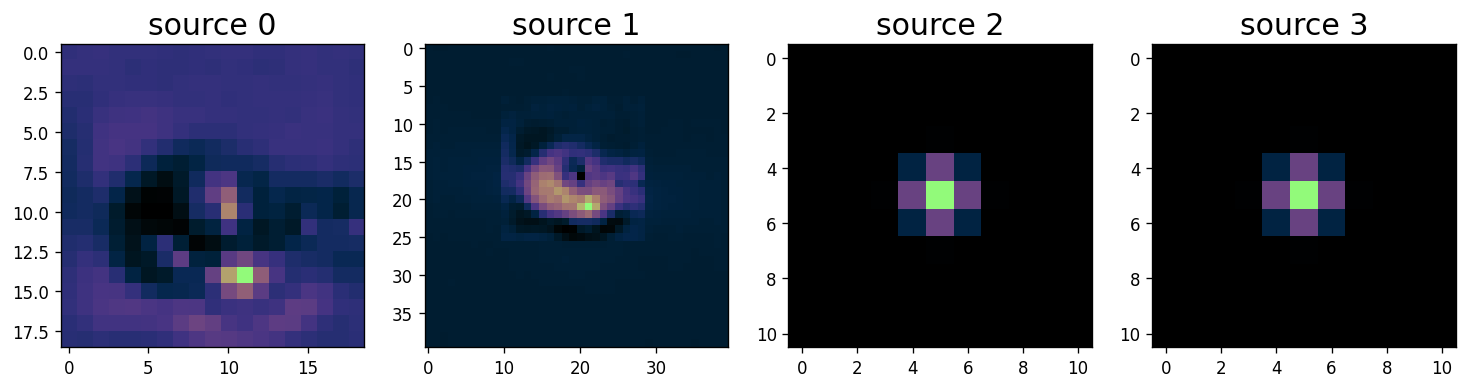

<Figure size 640x480 with 0 Axes>

In [72]:
# fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
# for i, ax in enumerate(axes):
#     if True:#i!=indtransient:
#         y = scene_.sources[i].morphology#[0]
#     else:
#         y = scene_.sources[i].morphology.data
#     ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
#     ax.set_title(f"source {i}", fontsize = 18)
#     ax.invert_yaxis()
# plt.show()
# plt.clf()



cmap = cmr.lilac
int_method='none'
fig, axes = plt.subplots(1, len( scene_.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if is_extended[i]==True:#i!=indtransient:
        y = np.array(scene_.sources[i].morphology)  # should work if it's already 2D or 3D
    else:
        y = scene_.sources[i].morphology()
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()
plt.savefig(str(img_index)+'_source_models_postfit.png')
plt.show()
plt.clf()

## Get variance of residuals

In [39]:
# import numpy as np
# import jax.numpy as jnp
# import pickle

# def compute_variance_array_for_point_sources_bbox(
#     scene,
#     observation,
#     point_source_indices,
#     rubin_bands,
#     band_epoch_indices,
#     max_epochs,
# ):
#     """
#     Do exactly what your advisor said:

#     For each point source (in its Scarlet bbox), for each band+epoch channel,
#     take the residual image (data - model), cut out that box, and compute
#     np.var(...) of the pixels in that box.

#     Returns
#     -------
#     var_output_array : list
#         Same shape as your flux_data: [bands][epochs][sources]
#     """

#     # If we got a list/tuple of observations, just use the first
#     if isinstance(observation, (list, tuple)):
#         obs = observation[0]
#     else:
#         obs = observation

#     # --- residual image, exactly as in scene() ---
#     model_scene = scene()
#     model_rendered = obs.render(model_scene)
#     data = obs.data
#     residual = data - model_rendered      # shape: (n_channels, ny, nx)
#     ny, nx = residual.shape[-2], residual.shape[-1]

#     # initialize: dict[band][epoch][source] = variance
#     var_array = {
#         band: [[np.nan for _ in range(len(point_source_indices))]
#                for _ in range(max_epochs[band])]
#         for band in rubin_bands
#     }

#     # loop over point sources
#     for local_idx, src_idx in enumerate(point_source_indices):
#         src = scene.sources[src_idx]

#         # --- USE SCARLET'S OWN BOX, like in plot.scene() ---
#         start, stop = src.bbox.spatial.start, src.bbox.spatial.stop   # in SCENE frame
#         corners = jnp.array(
#             [
#                 start,
#                 jnp.array((start[0], stop[1])),
#                 stop,
#                 jnp.array((stop[0], start[1])),
#             ]
#         )
#         # transform box corners into OBSERVATION pixels
#         corners_obs = obs.frame.get_pixel(scene.frame.get_sky_coord(corners))
#         ys = np.array(corners_obs[:, 0])
#         xs = np.array(corners_obs[:, 1])

#         y0, y1 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
#         x0, x1 = int(np.floor(xs.min())), int(np.ceil(xs.max()))

#         # clip to image bounds
#         y0 = max(0, y0); y1 = min(ny, y1)
#         x0 = max(0, x0); x1 = min(nx, x1)

#         # --- now: for each band+epoch, grab that box & take np.var ---
#         for band in rubin_bands:
#             for epoch, ch_idx in band_epoch_indices[band]:
#                 patch = np.array(residual[ch_idx, y0:y1, x0:x1])

#                 # optionally ignore masked (zero-weight) pixels
#                 if hasattr(obs, "weights"):
#                     w = np.array(obs.weights[ch_idx, y0:y1, x0:x1])
#                     patch = patch[w > 0]

#                 if patch.size == 0:
#                     var_val = np.nan
#                 else:
#                     var_val = float(np.var(patch))  # <- EXACTLY what your advisor said

#                 var_array[band][epoch][local_idx] = var_val

#     # convert dict(band) -> list [bands][epochs][sources], same order as rubin_bands
#     var_output_array = [var_array[band] for band in rubin_bands]
#     return var_output_array


# var_output_array = compute_variance_array_for_point_sources_bbox(
#     scene_,
#     observations_sc2,
#     point_source_indices,
#     rubin_bands,
#     band_epoch_indices,
#     max_epochs,
# )

# with open(f"sc_fluxes/rubin_scarlet_variances_{img_index}{version}.pkl", "wb") as f:
#     pickle.dump(var_output_array, f)

# print("Saved variance array with same shape as flux_data.")


In [40]:
# import numpy as np
# import jax.numpy as jnp
# import pickle

# rubin_bands = ['g', 'r', 'i']  # or ['lsstg','lsstr','lssti'] if that's what channels store

# # point sources
# point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
# num_point_sources = len(point_source_indices)

# # map (band, epoch) -> channel index, same as for flux
# band_epoch_indices = {band: [] for band in rubin_bands}
# for ch_idx, (band, epoch) in enumerate(channels):
#     if band in rubin_bands:
#         band_epoch_indices[band].append((int(epoch), ch_idx))

# max_epochs = {
#     band: max(e for e, _ in idxs) + 1
#     for band, idxs in band_epoch_indices.items()
# }

# def compute_flux_error_array(scene, observation, point_source_indices,
#                              rubin_bands, band_epoch_indices, max_epochs):
#     # handle list/tuple of observations: use first one (like your flux-setup case)
#     if isinstance(observation, (list, tuple)):
#         obs = observation[0]
#     else:
#         obs = observation

#     # model & residual
#     model = scene()
#     model_rendered = obs.render(model)
#     data = obs.data
#     residual = data - model_rendered      # shape: (n_channels, ny, nx)
#     ny, nx = residual.shape[-2], residual.shape[-1]

#     # initialize: bands × epochs × sources
#     err_array = {
#         band: [[0.0 for _ in range(len(point_source_indices))]
#                for _ in range(max_epochs[band])]
#         for band in rubin_bands
#     }

#     for local_idx, src_idx in enumerate(point_source_indices):
#         src = scene.sources[src_idx]

#         # --- use Scarlet's own bbox, transformed to obs pixels (like plot.scene) ---
#         start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
#         corners = jnp.array(
#             [
#                 start,
#                 jnp.array((start[0], stop[1])),
#                 stop,
#                 jnp.array((stop[0], start[1])),
#             ]
#         )
#         corners_obs = obs.frame.get_pixel(scene.frame.get_sky_coord(corners))
#         ys = np.array(corners_obs[:, 0])
#         xs = np.array(corners_obs[:, 1])

#         y0, y1 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
#         x0, x1 = int(np.floor(xs.min())), int(np.ceil(xs.max()))

#         # clip to image
#         y0 = max(0, y0); y1 = min(ny, y1)
#         x0 = max(0, x0); x1 = min(nx, x1)

#         if y1 <= y0 or x1 <= x0:
#             # nothing in frame: huge error sentinel
#             for band in rubin_bands:
#                 for epoch, _ in band_epoch_indices[band]:
#                     err_array[band][epoch][local_idx] = 1e10
#             continue

#         # spatial pixel count (not including channel axis)
#         n_pix_spatial = (y1 - y0) * (x1 - x0)

#         for band in rubin_bands:
#             for epoch, ch_idx in band_epoch_indices[band]:
#                 # residual slice for that band+epoch
#                 patch = np.array(residual[ch_idx, y0:y1, x0:x1])

#                 if hasattr(obs, "weights"):
#                     w = np.array(obs.weights[ch_idx, y0:y1, x0:x1])
#                     patch = patch[w > 0]

#                 if patch.size == 0:
#                     flux_err = 1e10
#                 else:
#                     # 1) pixel variance in the box
#                     pixel_var = np.var(patch)
#                     # 2) flux variance if flux ≈ sum of those pixels
#                     flux_var = n_pix_spatial * pixel_var
#                     # 3) 1σ flux error
#                     flux_err = float(np.sqrt(flux_var))

#                 err_array[band][epoch][local_idx] = flux_err

#     # turn dict into list in band order
#     final_error_array = [err_array[band] for band in rubin_bands]
#     return final_error_array


# error_array = compute_flux_error_array(
#     scene_,
#     observations_sc2,
#     point_source_indices,
#     rubin_bands,
#     band_epoch_indices,
#     max_epochs,
# )

# with open(f"sc_fluxes/rubin_scarlet_errors_{img_index}{version}.pkl", "wb") as f:
#     pickle.dump(error_array, f)

# print("Saved flux errors with same shape as fluxes.")


In [41]:
import numpy as np
import jax.numpy as jnp
import pickle

# --- Setup indices (Same as before) ---
rubin_bands = ['g', 'r', 'i'] 

# Point sources only
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]

# Map (band, epoch) -> channel index
band_epoch_indices = {band: [] for band in rubin_bands}
for ch_idx, (band, epoch) in enumerate(channels):
    if band in rubin_bands:
        band_epoch_indices[band].append((int(epoch), ch_idx))

max_epochs = {
    band: max(e for e, _ in idxs) + 1 if idxs else 0
    for band, idxs in band_epoch_indices.items()
}

def compute_flux_error_array(scene, observations, point_source_indices,
                             rubin_bands, channels, max_epochs):
    
    # Initialize: bands × epochs × sources
    err_array = {
        band: [[0.0 for _ in range(len(point_source_indices))]
               for _ in range(max_epochs[band])]
        for band in rubin_bands
    }

    # Generate the model once
    model = scene()

    # --- FIX: Loop over the observations list directly ---
    # Assuming 'observations' list aligns with 'channels' list 1-to-1
    for ch_idx, obs in enumerate(observations):
        
        # Get metadata for this specific observation
        band, epoch = channels[ch_idx]
        epoch = int(epoch)
        
        # Skip if not a band we care about
        if band not in rubin_bands:
            continue

        # 1. Render and Compute Residual for THIS observation
        try:
            model_rendered = obs.render(model)
            residual = obs.data - model_rendered
            # Note: obs.data usually (C, Y, X). For single obs, C=0 often.
            
            # If residual is (1, Y, X), grab the 2D image
            if residual.ndim == 3:
                residual_img = residual[0]
                if hasattr(obs, "weights"):
                    weight_img = obs.weights[0]
                else:
                    weight_img = np.ones_like(residual_img)
            else:
                residual_img = residual
                weight_img = np.ones_like(residual)

            ny, nx = residual_img.shape

            # 2. Loop over sources to measure variance in this specific frame
            for local_idx, src_idx in enumerate(point_source_indices):
                src = scene.sources[src_idx]

                # -- Bounding Box Logic --
                start, stop = src.bbox.spatial.start, src.bbox.spatial.stop
                
                # Create corners in Model Frame
                corners = jnp.array([
                    start,
                    jnp.array((start[0], stop[1])),
                    stop,
                    jnp.array((stop[0], start[1])),
                ])
                
                # Transform corners to Observation Frame (Pixel coordinates)
                corners_obs = obs.frame.get_pixel(scene.frame.get_sky_coord(corners))
                ys = np.array(corners_obs[:, 0])
                xs = np.array(corners_obs[:, 1])

                # Get integer bounds
                y0, y1 = int(np.floor(ys.min())), int(np.ceil(ys.max()))
                x0, x1 = int(np.floor(xs.min())), int(np.ceil(xs.max()))

                # Clip to image bounds
                y0 = max(0, y0); y1 = min(ny, y1)
                x0 = max(0, x0); x1 = min(nx, x1)

                # Check if source is valid in this frame
                if y1 <= y0 or x1 <= x0:
                    err_array[band][epoch][local_idx] = 1e10
                    continue

                # Extract cutout
                patch = np.array(residual_img[y0:y1, x0:x1])
                w_patch = np.array(weight_img[y0:y1, x0:x1])

                # Filter for valid pixels
                valid_pixels = patch[w_patch > 0]

                if valid_pixels.size == 0:
                    flux_err = 1e10
                else:
                    # 1) Variance per pixel
                    pixel_var = np.var(valid_pixels)
                    
                    # 2) Flux Error = sqrt(N * sigma^2)
                    # N should be the number of valid pixels contributing to the sum
                    N = valid_pixels.size
                    flux_err = float(np.sqrt(N * pixel_var))

                err_array[band][epoch][local_idx] = flux_err

        except Exception as e:
            print(f"Error processing obs {ch_idx} ({band} {epoch}): {e}")
            # Fill defaults for this whole epoch if render fails
            for local_idx in range(len(point_source_indices)):
                err_array[band][epoch][local_idx] = 1e10

    # Reformat dictionary to list
    final_error_array = [err_array[band] for band in rubin_bands]
    return final_error_array

# --- Execution ---
error_array = compute_flux_error_array(
    scene_,
    observations_sc2, # Pass the full list
    point_source_indices,
    rubin_bands,
    channels,         # Pass channels to map list index to band/epoch
    max_epochs
)

with open(f"sc_fluxes/rubin_scarlet_errors_{img_index}{version}.pkl", "wb") as f:
    pickle.dump(error_array, f)

print("Saved flux errors.")

Saved flux errors.
